In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv")

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Input

In [29]:
print(df.shape)
df.head()

(14096, 95)


,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


In [5]:
pitch_outcome_num = []
for i in range(df.shape[0]):
    if df.loc[i, 'description'] in ['called_strike', 'foul', 'swinging_strike', 'foul_tip']:
        pitch_outcome_num.append(1)
    elif df.loc[i, 'description'] == 'ball':
        pitch_outcome_num.append(0)
    else:
        pitch_outcome_num.append(2)

# Probaility at each count

[0, 0] Count: probability of strike = 0.5970341715022566 probability of ball = 0.40296582849774343
[1, 0] Count: probability of strike = 0.6267154620311071 probability of ball = 0.37328453796889294
[2, 0] Count: probability of strike = 0.6412429378531074 probability of ball = 0.3587570621468926
[3, 0] Count: probability of strike = 0.6390977443609023 probability of ball = 0.3609022556390977
[0, 1] Count: probability of strike = 0.5275103163686382 probability of ball = 0.4724896836313618
[1, 1] Count: probability of strike = 0.5983899821109123 probability of ball = 0.4016100178890877
[2, 1] Count: probability of strike = 0.6559714795008913 probability of ball = 0.3440285204991087
[3, 1] Count: probability of strike = 0.7046413502109705 probability of ball = 0.2953586497890295
[0, 2] Count: probability of strike = 0.4786666666666667 probability of ball = 0.5213333333333333
[1, 2] Count: probability of strike = 0.5123152709359606 probability of ball = 0.48768472906403937
[2, 2] Count: pro

Text(0, 0.5, 'Probability of strike')

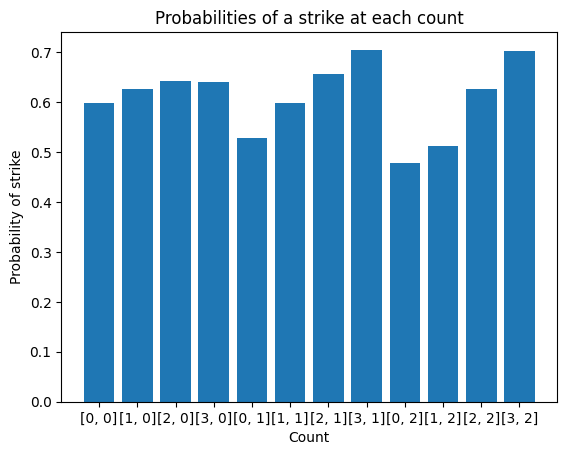

In [6]:
counts = []
unique_counts = []
for i in range(len(pitch_outcome_num)):
    count = [df.loc[i, 'balls'], df.loc[i, 'strikes']]
    counts.append(count)
    if count not in unique_counts:
        unique_counts.append(count)
#e
count_0_0 = []
count_1_0 = []
count_2_0 = []
count_3_0 = []
count_0_1 = []
count_1_1 = []
count_2_1 = []
count_3_1 = []
count_0_2 = []
count_1_2 = []
count_2_2 = []
count_3_2 = []
#seperating outcomes by count
for i in range(len(counts)):
    if counts[i] == [0,0]:
        if pitch_outcome_num[i] != 2:
            count_0_0.append(pitch_outcome_num[i])
    elif counts[i] == [1,0]:
        if pitch_outcome_num[i] != 2:
            count_1_0.append(pitch_outcome_num[i])
    elif counts[i] == [2,0]:
        if pitch_outcome_num[i] != 2:
            count_2_0.append(pitch_outcome_num[i])
    elif counts[i] == [3,0]:
        if pitch_outcome_num[i] != 2:
            count_3_0.append(pitch_outcome_num[i])
    elif counts[i] == [0,1]:
        if pitch_outcome_num[i] != 2:
            count_0_1.append(pitch_outcome_num[i])
    elif counts[i] == [1,1]:
        if pitch_outcome_num[i] != 2:
            count_1_1.append(pitch_outcome_num[i])
    elif counts[i] == [2,1]:
        if pitch_outcome_num[i] != 2:
            count_2_1.append(pitch_outcome_num[i])
    elif counts[i] == [3,1]:
        if pitch_outcome_num[i] != 2:
            count_3_1.append(pitch_outcome_num[i])
    elif counts[i] == [0,2]:
        if pitch_outcome_num[i] != 2:
            count_0_2.append(pitch_outcome_num[i])
    elif counts[i] == [1,2]:
        if pitch_outcome_num[i] != 2:
            count_1_2.append(pitch_outcome_num[i])
    elif counts[i] == [2,2]:
        if pitch_outcome_num[i] != 2:
            count_2_2.append(pitch_outcome_num[i])
    elif counts[i] == [3,2]:
        if pitch_outcome_num[i] != 2:
            count_3_2.append(pitch_outcome_num[i])
#determing probability
s_prob_list = []

s_prob = np.mean(count_0_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[0, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_1_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[1, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_2_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[2, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_3_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[3, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_0_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[0, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_1_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[1, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_2_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[2, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_3_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[3, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_0_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[0, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_1_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[1, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_2_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[2, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_3_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[3, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

names = ["[0, 0]", "[1, 0]", "[2, 0]", "[3, 0]", "[0, 1]", "[1, 1]","[2, 1]","[3, 1]", "[0, 2]", "[1, 2]", "[2, 2]", "[3, 2]",]

plt.bar(names, s_prob_list)
plt.title("Probabilities of a strike at each count")
plt.xlabel("Count")
plt.ylabel("Probability of strike")

0 Outs probability of strike = 0.6646341463414634 probability of ball = 0.33536585365853655
1 Outs probability of strike = 0.7288135593220338 probability of ball = 0.27118644067796616
2 Outs probability of strike = 0.7133333333333334 probability of ball = 0.2866666666666666


Text(0, 0.5, 'Probability of strike')

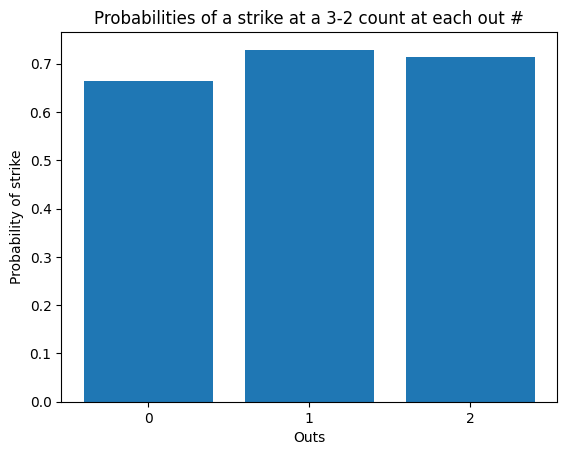

In [7]:
outs_0 = []
outs_1 = []
outs_2 = []
for i in range(df.shape[0]):
    if counts[i] == [3, 2] and pitch_outcome_num[i] != 2:
        if df.loc[i, 'outs_when_up'] == 0:
            outs_0.append(pitch_outcome_num[i])
        elif df.loc[i, 'outs_when_up'] == 1:
            outs_1.append(pitch_outcome_num[i])
        elif df.loc[i, 'outs_when_up'] == 2:
            outs_2.append(pitch_outcome_num[i])

s_prob_list = []

s_prob = np.mean(outs_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("0 Outs", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(outs_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("1 Outs", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(outs_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("2 Outs", "probability of strike =", s_prob, "probability of ball =", b_prob)

outs = ['0', '1', '2']

plt.bar(outs, s_prob_list)
plt.title("Probabilities of a strike at a 3-2 count at each out #")
plt.xlabel("Outs")
plt.ylabel("Probability of strike")

# Machine Learning Stuff

In [8]:
df['outcome'] = pitch_outcome_num
smaller = df[['balls', 'strikes', 'inning', 'inning_topbot', 'at_bat_number', 'pitch_number', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up',
              'bat_score', 'fld_score', 'if_fielding_alignment', 'of_fielding_alignment', 'outcome']]
smaller.head()

,balls,strikes,inning,inning_topbot,at_bat_number,pitch_number,on_3b,on_2b,on_1b,outs_when_up,bat_score,fld_score,if_fielding_alignment,of_fielding_alignment,outcome
0,0,0,8,Bot,73,1,NaN,NaN,NaN,0,10,5,Standard,Standard,0
1,1,0,8,Bot,73,2,NaN,NaN,NaN,0,10,5,Standard,Standard,1
2,1,1,8,Bot,73,3,NaN,NaN,NaN,0,10,5,Standard,Standard,1
3,1,2,8,Bot,73,4,NaN,NaN,NaN,0,10,5,Standard,Standard,1
4,1,2,8,Bot,73,5,NaN,NaN,NaN,0,10,5,Standard,Standard,0


Make the on base columns either one or zero because we don't care whos on base

In [9]:
for i in range(df.shape[0]):
    if smaller.loc[i, 'on_3b'] == None:
        smaller.loc[i, 'on_3b'] = 0
    else:
        smaller.loc[i, 'on_3b'] = 1
smaller.head()

,balls,strikes,inning,inning_topbot,at_bat_number,pitch_number,on_3b,on_2b,on_1b,outs_when_up,bat_score,fld_score,if_fielding_alignment,of_fielding_alignment,outcome
0,0,0,8,Bot,73,1,1.0,NaN,NaN,0,10,5,Standard,Standard,0
1,1,0,8,Bot,73,2,1.0,NaN,NaN,0,10,5,Standard,Standard,1
2,1,1,8,Bot,73,3,1.0,NaN,NaN,0,10,5,Standard,Standard,1
3,1,2,8,Bot,73,4,1.0,NaN,NaN,0,10,5,Standard,Standard,1
4,1,2,8,Bot,73,5,1.0,NaN,NaN,0,10,5,Standard,Standard,0


In [10]:
for i in range(df.shape[0]):
    if smaller.loc[i, 'on_2b'] == None:
        smaller.loc[i, 'on_2b'] = 0
    else:
        smaller.loc[i, 'on_2b'] = 1

for i in range(df.shape[0]):
    if smaller.loc[i, 'on_1b'] == None:
        smaller.loc[i, 'on_1b'] = 0
    else:
        smaller.loc[i, 'on_1b'] = 1
smaller.head()

,balls,strikes,inning,inning_topbot,at_bat_number,pitch_number,on_3b,on_2b,on_1b,outs_when_up,bat_score,fld_score,if_fielding_alignment,of_fielding_alignment,outcome
0,0,0,8,Bot,73,1,1.0,1.0,1.0,0,10,5,Standard,Standard,0
1,1,0,8,Bot,73,2,1.0,1.0,1.0,0,10,5,Standard,Standard,1
2,1,1,8,Bot,73,3,1.0,1.0,1.0,0,10,5,Standard,Standard,1
3,1,2,8,Bot,73,4,1.0,1.0,1.0,0,10,5,Standard,Standard,1
4,1,2,8,Bot,73,5,1.0,1.0,1.0,0,10,5,Standard,Standard,0


In [14]:
drop_hits = smaller[smaller['outcome'] != 2]

In [19]:
x = pd.get_dummies(drop_hits.drop(['outcome', 'at_bat_number'], axis=1))
y = drop_hits['outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2)

x_train.head()

,balls,strikes,inning,pitch_number,on_3b,on_2b,on_1b,outs_when_up,bat_score,fld_score,inning_topbot_Bot,inning_topbot_Top,if_fielding_alignment_Infield shade,if_fielding_alignment_Standard,if_fielding_alignment_Strategic,of_fielding_alignment_Standard,of_fielding_alignment_Strategic
10243,2,1,2,4,1.0,1.0,1.0,1,1,1,False,True,False,True,False,True,False
12577,1,0,13,2,1.0,1.0,1.0,1,5,5,True,False,False,False,True,False,True
6523,1,2,6,4,1.0,1.0,1.0,1,3,3,False,True,True,False,False,True,False
11739,1,2,8,5,1.0,1.0,1.0,1,4,11,False,True,True,False,False,True,False
4501,0,1,5,2,1.0,1.0,1.0,2,0,1,False,True,False,True,False,True,False


In [24]:
model = Sequential()
model.add(Input(shape=(len(x_train.columns),)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [25]:
model.fit(x_train, y_train, epochs=200, batch_size = 12)

Epoch 1/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step - accuracy: 0.5804 - loss: 0.6813
Epoch 2/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.5834 - loss: 0.6752
Epoch 3/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.5866 - loss: 0.6732
Epoch 4/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - accuracy: 0.5894 - loss: 0.6729
Epoch 5/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.5863 - loss: 0.6720
Epoch 6/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.5900 - loss: 0.6716
Epoch 7/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.5945 - loss: 0.6706
Epoch 8/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.5881 - loss: 0.6711
Epoch 9/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - accuracy: 0.5913 - loss: 0.6708
Epoch 10/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.5926 - loss: 0.6701
Epoch 11/200
746/746 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.5924 - loss: 0.6692
Epoch 12/200
746/74

In [26]:
y_hat = model.predict(x_test)
y_hat = [0 if val <0.5 else 1 for val in y_hat]

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step


In [27]:
accuracy_score(y_test, y_hat)

0.5576923076923077